In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import os

In [2]:
def interpolate_row(row):
    """a method for interpolating a row to 100 values

    Parameters:
    row (dataframe record): the row to be interpolated to 100 frames

    Returns:
    interpolated_row (dataframe record): the interpolated row
    """
    non_nan_indices = np.where(~np.isnan(row))[0]
    if len(non_nan_indices) <= 1:
        return np.full(100, np.nan)
    interpolated_row = np.interp(
        np.linspace(0, 1, 100),
        np.linspace(0, 1, len(non_nan_indices)),
        row[non_nan_indices],
    )
    return interpolated_row

In [3]:
def interpolate(df):

    # Interpolate data and shrink it to 100 frames
    data_array = df.to_numpy()
   
    interpolated_data = np.apply_along_axis(interpolate_row, axis=1, arr=data_array)

    X_data = pd.DataFrame(interpolated_data)


    return X_data


In [ ]:
# this code runs for all gaits of the dataframe without segmenting by label

# df = pd.read_csv("data_set\\courseA\\id01\\merged_step_count_wrist.csv")
# df = pd.read_csv("data_set\\courseA\\id01\\merged_gait_count_shank.csv")
df = pd.read_csv("data_set\\courseA\\id01\\merged_gait_count_annotations.csv")
df = df[['stepcount', 'jointAngleXZY_jRightKnee_z']]

# Pivot the dataframe to make 'stepcount' the index, and 'jointAngleXZY_jRightKnee_z' values in columns
df_pivot = df.pivot_table(index='stepcount', values='jointAngleXZY_jRightKnee_z', aggfunc=list)

# Convert the lists into separate columns by creating a new DataFrame
df_expanded = pd.DataFrame(df_pivot['jointAngleXZY_jRightKnee_z'].tolist(), index=df_pivot.index)

df_interpolated = interpolate(df_expanded)
# df_interpolated.to_csv("data_set\\courseA\\id01\\steps_wrist_interpolated.csv", index=False)
# df_interpolated.to_csv("data_set\\courseA\\id01\\gaits_shank_interpolated.csv", index=False)
df_interpolated.to_csv("data_set\\courseA\\id01\\gaits_annotations_interpolated.csv", index=False)

In [ ]:
# this code segments the labels individually
# df = pd.read_csv("data_set\\courseA\\id01\\merged_gait_count_shank.csv")
df = pd.read_csv("data_set\\courseA\\id01\\merged_gait_count_annotations.csv")

# Keep only relevant columns
df = df[['stepcount', 'jointAngleXZY_jLeftKnee_z', 'walk_mode']]
# df = df[['stepcount', 'gyrMagnitude_RightLowerLeg', 'walk_mode']]

# Output folder path for saving files
# output_folder = "data_set\\courseA\\id01\\shank_gaits_divided_by_label/"
# output_folder = "data_set\\courseA\\id01\\shank_gaits_magnitude_divided_by_label/"
output_folder = "data_set\\courseA\\id01\\annotation_gaits_divided_by_label/"

# Group by `walk_mode`
for label, group_df in df.groupby('walk_mode'):
    # Pivot the dataframe to make 'stepcount' the index, and 'jointAngleXZY_jRightKnee_z' values in columns
    df_pivot = group_df.pivot_table(index='stepcount', values='jointAngleXZY_jLeftKnee_z', aggfunc=list)
    # df_pivot = group_df.pivot_table(index='stepcount', values='gyrMagnitude_RightLowerLeg', aggfunc=list)

    # Convert the lists into separate columns by creating a new DataFrame
    df_expanded = pd.DataFrame(df_pivot['jointAngleXZY_jLeftKnee_z'].tolist(), index=df_pivot.index)
    # df_expanded = pd.DataFrame(df_pivot['gyrMagnitude_RightLowerLeg'].tolist(), index=df_pivot.index)
    
    # Interpolate the expanded dataframe
    df_interpolated = interpolate(df_expanded)

    # Save the interpolated dataframe to a CSV file with the `walk_mode` label in the filename
    # filename = f"{output_folder}gait_shank_interpolated_{label}.csv"
    filename = f"{output_folder}gait_annotations_interpolated_{label}.csv"
    df_interpolated.to_csv(filename, index=False)

print("Processing and saving complete.")

Processing and saving complete.


In [42]:
def plot_gait(df, gait):
    plt.figure(figsize=(20, 10))
    plt.plot(df.columns, df.iloc[gait-1], label=f"Gait {gait}")
    plt.xlabel("Frames")
    plt.ylabel("Amplitudes")
    plt.title(f"Gait Cycle - Step {gait}")
    plt.xticks(rotation=90)
    plt.legend()
    plt.show()

In [43]:
# this is for all the gait cycles combined regardless of the label

def plot_combined_gait_cycles(df):
    plt.figure(figsize=(16, 10))
    # Iterate over each row in the dataframe and plot it on the same figure
    for gait in df.index:
        plt.plot(df.columns, df.loc[gait])
    
    # Labeling and title
    plt.xlabel("Frames")
    plt.ylabel("Amplitudes")
    plt.title("Gait Cycles Combined")
    plt.xticks(rotation=90)

    # Show the plot
    plt.show()

In [5]:
# this does the same but each label in a subplot

def plot_combined_gait_cycles_by_labels(folder_path):
    # Fetch all CSV file paths in the specified folder
    file_paths = glob.glob(os.path.join(folder_path, "*.csv"))
    # Determine number of files and subplot grid size
    num_files = len(file_paths)
    # Create a vertical stack of subplots (one column, multiple rows)
    fig, axes = plt.subplots(nrows=num_files, ncols=1, figsize=(10, 3 * num_files), sharex=True)
    
    # Ensure `axes` is always iterable, even if there's only one subplot
    if num_files == 1:
        axes = [axes]
    
    # Iterate over each file and subplot
    for i, file_path in enumerate(file_paths):
        # Read the dataframe
        df = pd.read_csv(file_path)
        
        # Plot each row (gait cycle) in the respective subplot
        for gait in df.index:
            axes[i].plot(df.columns, df.loc[gait])

        # Labeling and subplot title
        axes[i].set_title(f"Gait Cycle for {os.path.basename(file_path)}")
        axes[i].set_ylabel("Amplitudes")
        axes[i].tick_params(axis='x', rotation=90)  # Rotate x-axis labels vertically
    
    # Add common x-axis label at the bottom
    fig.supxlabel("Frames")
    fig.suptitle("Combined Gait Cycles Across Labels", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for main title
    plt.show()

In [ ]:
# data = "data_set\\courseA\\id01\\steps_wrist_interpolated.csv"
data = "data_set\\courseA\\id01\\gaits_shank_interpolated.csv"
df = pd.read_csv(data)
plot_gait(df, 15)

In [ ]:
# data = "data_set\\courseA\\id01\\steps_wrist_interpolated.csv"
data = "data_set\\courseA\\id01\\gaits_shank_interpolated.csv"
df = pd.read_csv(data)
plot_combined_gait_cycles(df)

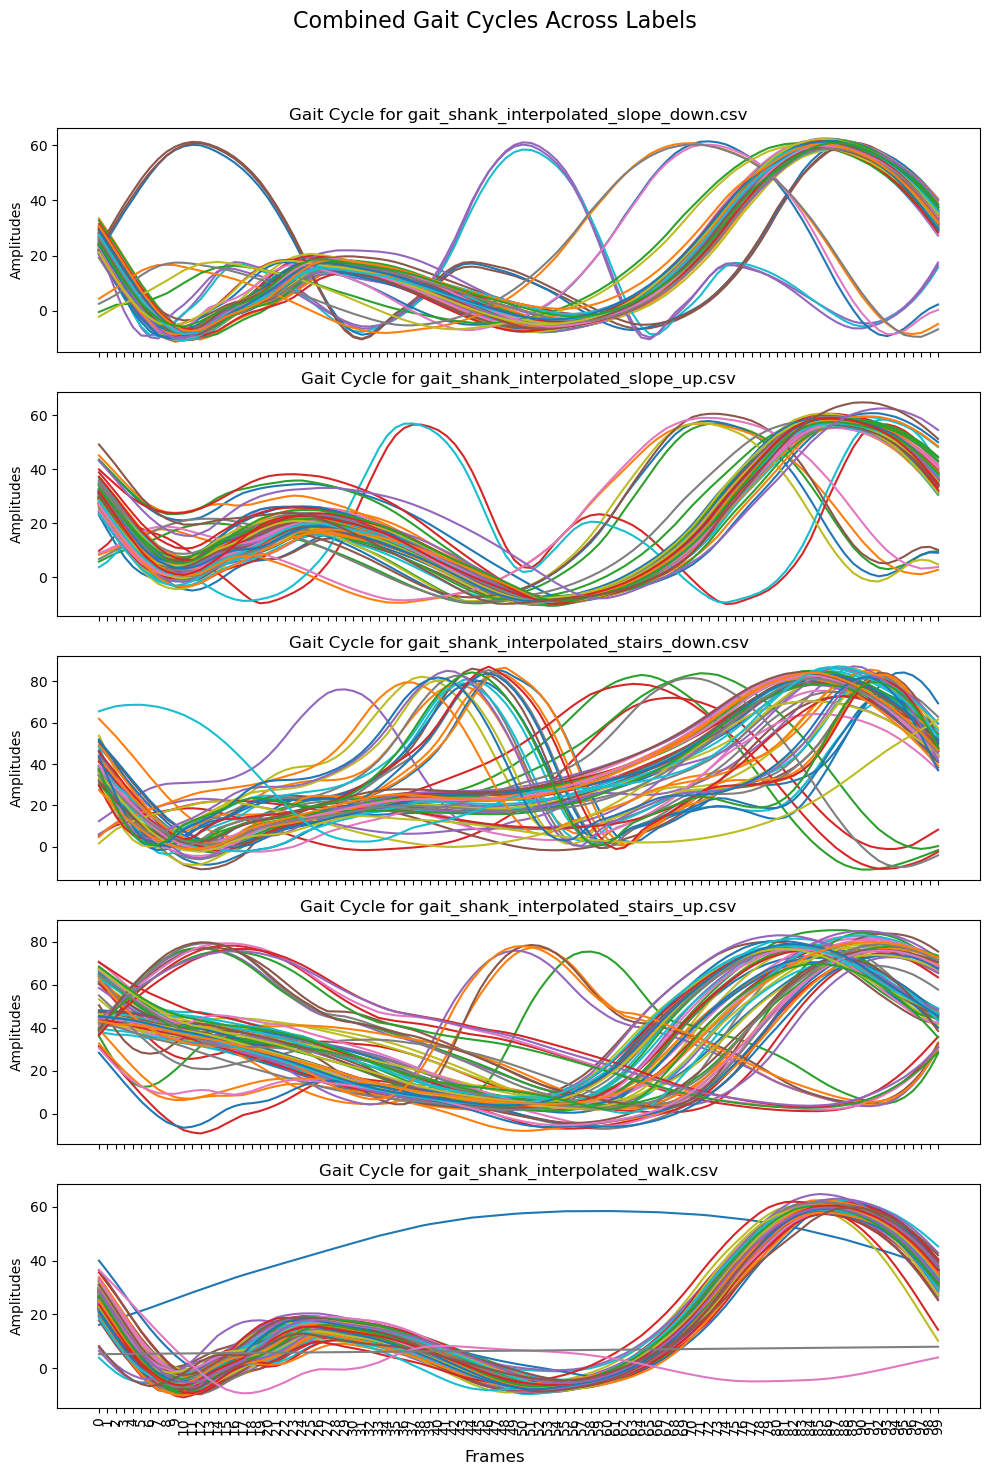

In [6]:
# Define the folder path and call the function
folder_path = "data_set\\courseA\\id01\\shank_gaits_divided_by_label"
plot_combined_gait_cycles_by_labels(folder_path)

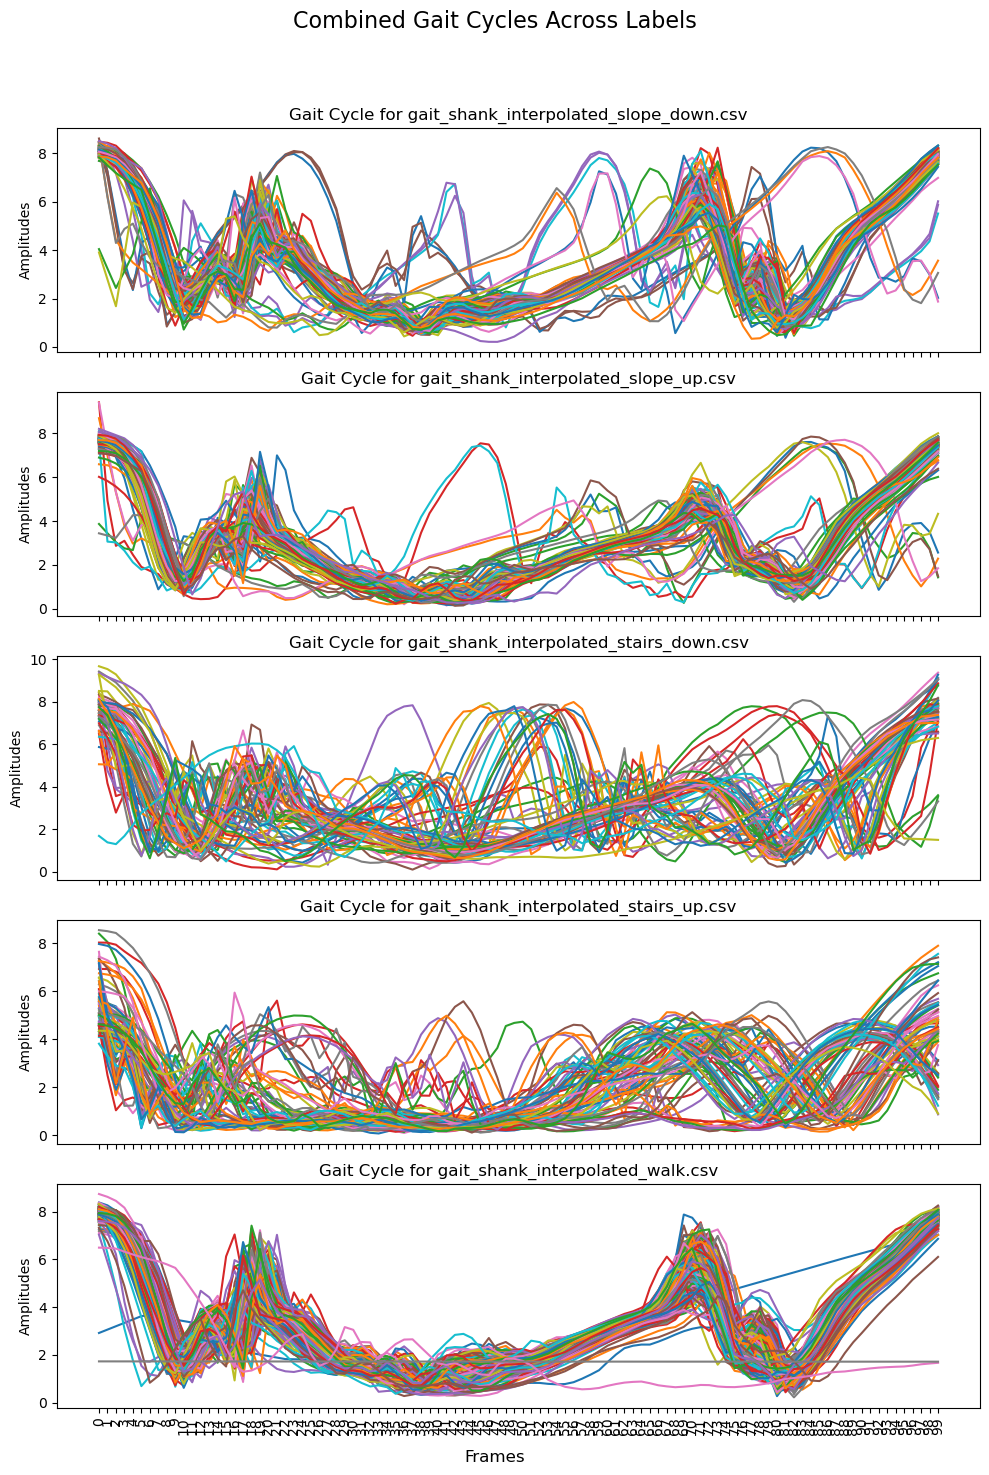

In [7]:
# Define the folder path and call the function
folder_path = "data_set\\courseA\\id01\\shank_gaits_magnitude_divided_by_label"
plot_combined_gait_cycles_by_labels(folder_path)

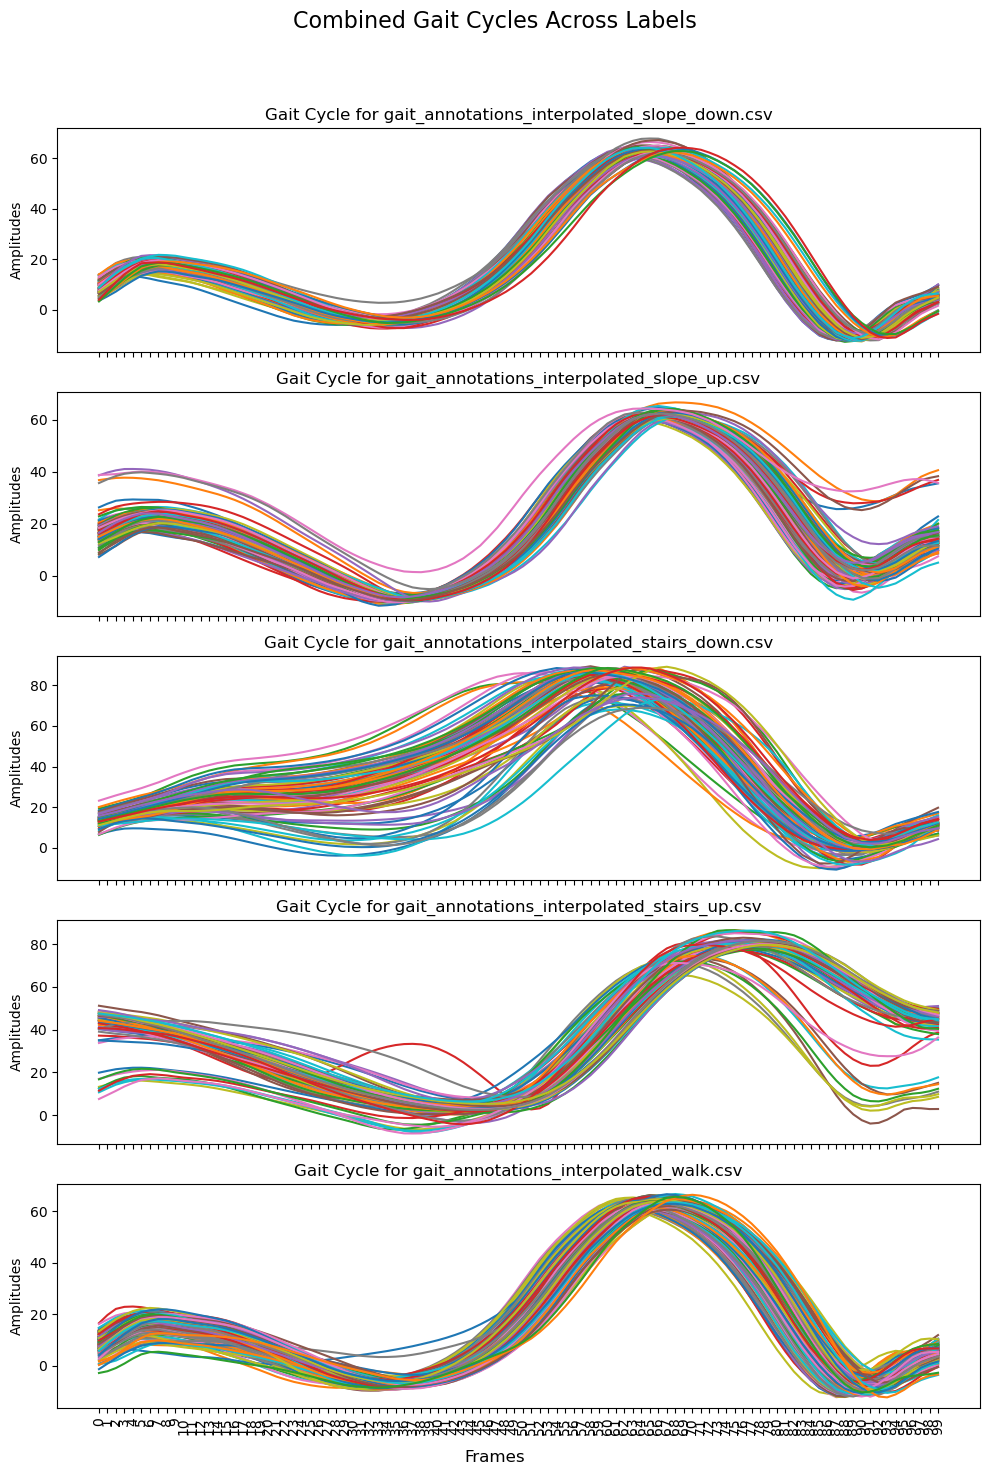

In [6]:
# Define the folder path and call the function
folder_path = "data_set\\courseA\\id01\\annotation_gaits_divided_by_label"
plot_combined_gait_cycles_by_labels(folder_path)

In [ ]:
def create_plot_data(folder_path):
    print("Working on file", folder_path)
    # this code segments the labels individually
    df = pd.read_csv(os.path.join(folder_path, "merged_gait_count_annotations.csv"))

    # Keep only relevant columns
    df = df[['stepcount', 'jointAngleXZY_jLeftKnee_z', 'walk_mode']]

    
    output_folder = os.path.join(folder_path, "annotation_gaits_divided_by_label")
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # Group by `walk_mode`
    for label, group_df in df.groupby('walk_mode'):
        # Pivot the dataframe to make 'stepcount' the index, and 'jointAngleXZY_jRightKnee_z' values in columns
        df_pivot = group_df.pivot_table(index='stepcount', values='jointAngleXZY_jLeftKnee_z', aggfunc=list)

        # Convert the lists into separate columns by creating a new DataFrame
        df_expanded = pd.DataFrame(df_pivot['jointAngleXZY_jLeftKnee_z'].tolist(), index=df_pivot.index)
        
        # Interpolate the expanded dataframe
        df_interpolated = interpolate(df_expanded)

        # Save the interpolated dataframe to a CSV file with the `walk_mode` label in the filename
        filename = f"{output_folder}\\gait_annotations_interpolated_{label}.csv"
        df_interpolated.to_csv(filename, index=False)

In [ ]:
dataset_path = "data_set"

print("Creating plot_data...")
# Iterate through the directory structure
for course_folder in os.listdir(dataset_path):
    course_folder_path = os.path.join(dataset_path, course_folder)
    if os.path.isdir(course_folder_path):
        for subfolder in os.listdir(course_folder_path):
            subfolder_path = os.path.join(course_folder_path, subfolder)
            if os.path.isdir(subfolder_path):
                create_plot_data(subfolder_path)
print("Plot data created successfully")

In [15]:
# this does the same but each label in a subplot

def plot_combined_gait_cycles_by_labels(folder_path):
    # Fetch all CSV file paths in the specified folder
    file_paths = glob.glob(os.path.join(folder_path, "*.csv"))
    # Determine number of files and subplot grid size
    num_files = len(file_paths)
    # Create a vertical stack of subplots (one column, multiple rows)
    fig, axes = plt.subplots(nrows=num_files, ncols=1, figsize=(10, 3 * num_files), sharex=True)
    
    # Ensure `axes` is always iterable, even if there's only one subplot
    if num_files == 1:
        axes = [axes]
    
    # Iterate over each file and subplot
    for i, file_path in enumerate(file_paths):
        # Read the dataframe
        df = pd.read_csv(file_path)
        
        # Plot each row (gait cycle) in the respective subplot
        for gait in df.index:
            axes[i].plot(df.columns, df.loc[gait])

        # Labeling and subplot title
        axes[i].set_title(f"Gait Cycle for {os.path.basename(file_path)}")
        axes[i].set_ylabel("Amplitudes")
        axes[i].tick_params(axis='x', rotation=90)  # Rotate x-axis labels vertically
    
    # Add common x-axis label at the bottom
    fig.supxlabel("Frames")
    fig.suptitle("Combined Gait Cycles Across Labels", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for main title
    plt.show()

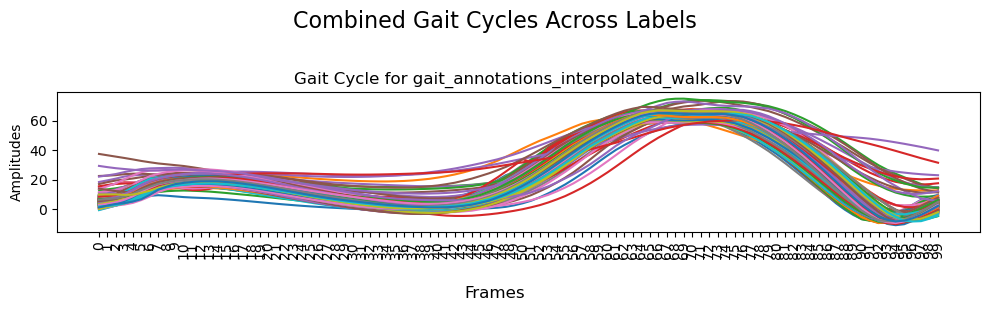

In [30]:
# Define the folder path and call the function
folder_path = "data_set\\courseC\\id02\\annotation_gaits_divided_by_label"
plot_combined_gait_cycles_by_labels(folder_path)

In [6]:
def plot_combined_gait_cycles_by_file_type(base_folder):
    """
    Plots gait cycle data for predefined file names across all participants and courses.
    Each subplot combines data from all participants for the same file name.
    """
    # List of specific file names to search for
    file_names = [
        "gait_annotations_interpolated_slope_down.csv",
        "gait_annotations_interpolated_slope_up.csv",
        "gait_annotations_interpolated_stairs_down.csv",
        "gait_annotations_interpolated_stairs_up.csv",
        "gait_annotations_interpolated_walk.csv"
    ]
    
    # Create a subplot for each file type
    num_files = len(file_names)
    fig, axes = plt.subplots(nrows=num_files, ncols=1, figsize=(10, 3 * num_files), sharex=True)
    
    # Ensure axes is iterable even for a single subplot
    if num_files == 1:
        axes = [axes]
    
    # Iterate through each file name to plot its data
    for i, file_name in enumerate(file_names):
        # Gather all paths for the current file name across the folder structure
        search_pattern = os.path.join(base_folder, "course*", "id*", "annotation_gaits_divided_by_label", file_name)
        file_paths = glob.glob(search_pattern)
        
        if not file_paths:
            axes[i].set_title(f"No data for {file_name}")
            axes[i].set_ylabel("Amplitudes")
            continue  # Skip if no files found for this type
        
        # Plot all files of the current type in the same subplot
        for file_path in file_paths:
            # Read the CSV file
            df = pd.read_csv(file_path)

            # Slice the columns starting from the 10th one (index 9 onward)
            sliced_data = df.iloc[:, 9:]
            
            # # Plot each row (gait cycle) on the same subplot
            # for gait in sliced_data.index:
            #     axes[i].plot(sliced_data.columns, sliced_data.loc[gait], label=os.path.basename(os.path.dirname(file_path)), alpha=0.6)
            # Plot each row (gait cycle) on the same subplot
            for gait in df.index:
                axes[i].plot(df.columns, df.loc[gait], label=os.path.basename(os.path.dirname(file_path)), alpha=0.6)
        
        # Set titles and labels for the subplot
        axes[i].set_title(f"Combined Data for {file_name}")
        axes[i].set_ylabel("Amplitudes")
        axes[i].tick_params(axis='x', rotation=90)  # Rotate x-axis labels vertically

    # Add common x-axis label and main title
    fig.supxlabel("Frames")
    fig.suptitle("Combined Gait Cycles Across All Participants by File Type", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for main title
    plt.show()


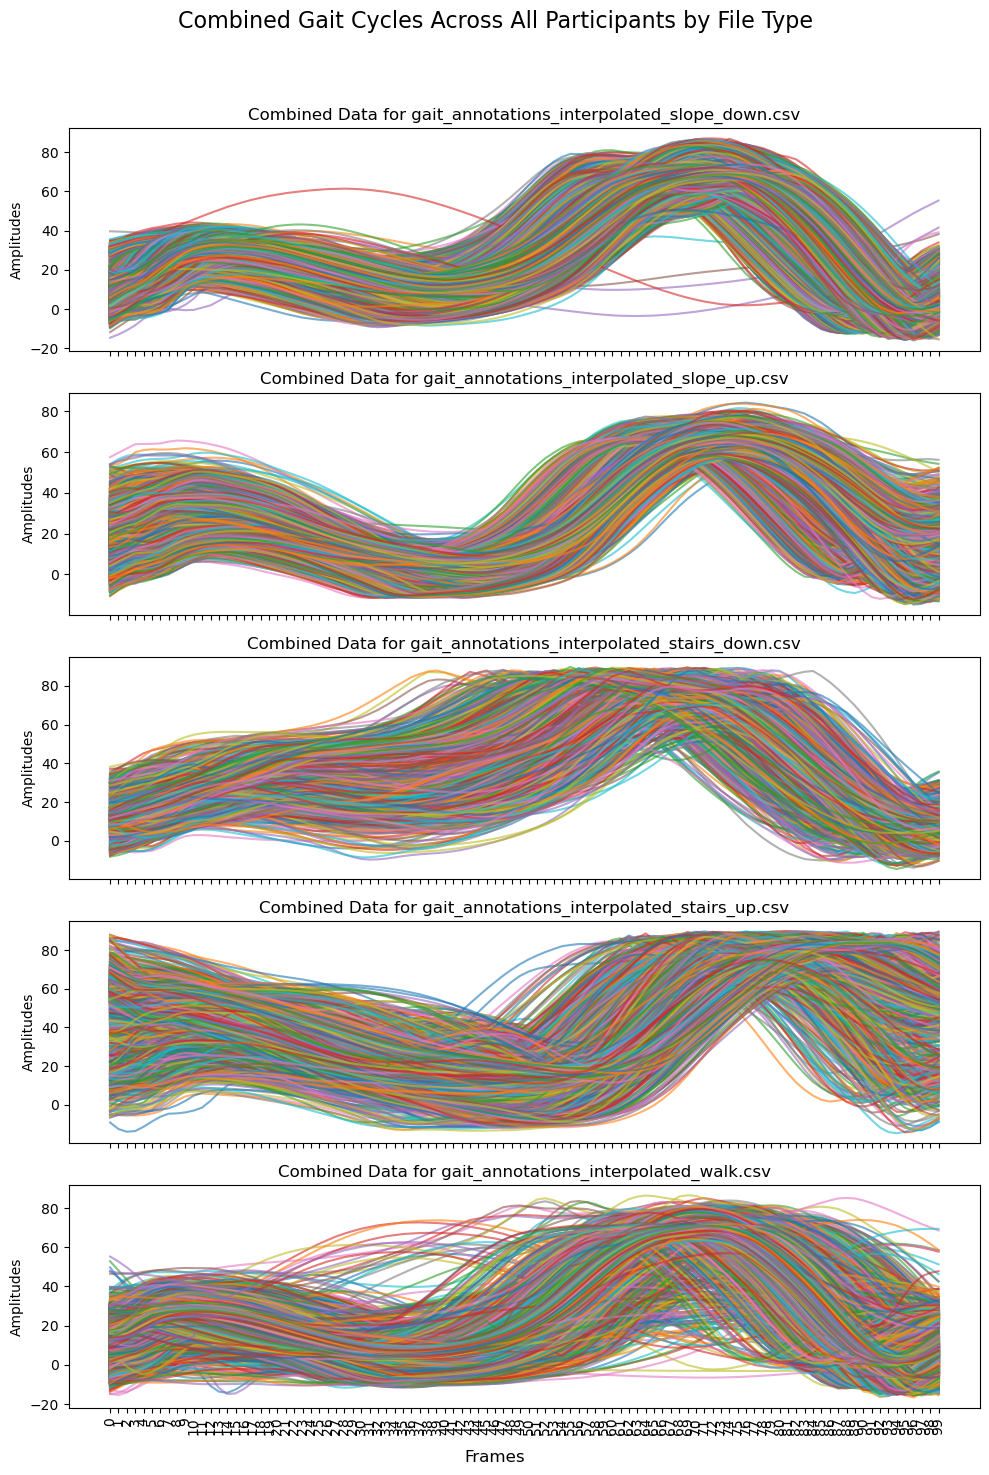

In [7]:
plot_combined_gait_cycles_by_file_type("data_set")